In [1]:
import gensim
import numpy as np
import csv
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
from sklearn.metrics import f1_score

In [2]:
trainingfile = "../../data/conll2003/conll2003.train.conll"
devfile = "../../data/conll2003/conll2003.dev.conll"
outputfile = "dev_predictions.conll"

In [3]:
def extract_features_and_labels(trainingfile):
    """
    Extracts one-hot features and gold labels from a file.
    Returns: list of dicts (features), list of str (labels)
    """
    data = []
    targets = []
    prev_token = None
    prev_pos = None
    
    with open(trainingfile, 'r', encoding='utf8') as infile:
        for line in infile:
            components = line.rstrip('\n').split()
            if len(components) > 0:
                token = components[0]
                pos_tag = components[1]
                chunk_tag = components[2]

                feature_dict = {
                    'token': token,
                    'token.lower()': token.lower(),
                    'is_capitalized': token[0].isupper(),
                    'is_all_caps': token.isupper(),
                    'is_all_lower': token.islower(),
                    'contains_digit': any(ch.isdigit() for ch in token),
                    'contains_hyphen': '-' in token,
                    'pos_tag': pos_tag,
                    'chunk_tag': chunk_tag,
                    'prev_token': prev_token if prev_token is not None else 'BOS',
                    'prev_pos': prev_pos if prev_pos is not None else 'BOS'
                }

                data.append(feature_dict)
                targets.append(components[-1])  # gold label

                # update context for next token
                prev_token = token
                prev_pos = pos_tag
    return data, targets


In [4]:
def extract_embeddings_as_features_and_gold(trainingfile, word_embedding_model):
    """
    Extracts word embeddings for tokens in a CONLL file.
    Returns: list of vectors, list of labels
    """
    features = []
    labels = []

    with open(trainingfile, 'r', encoding='utf8') as infile:
        csvreader = csv.reader(infile, delimiter='\t', quotechar='|')
        for row in csvreader:
            if len(row) > 3:
                token = row[0]
                vector = word_embedding_model[token] if token in word_embedding_model else [0]*300
                features.append(vector)
                labels.append(row[-1])
    return np.array(features), labels

In [5]:
from scipy.sparse import hstack, csr_matrix

def create_classifier(train_features, train_targets, modelname, train_embeddings=None):
    """
    Trains a classifier for NER.
    Concatenates embeddings only for SVM using sparse matrices to save memory.
    Returns: model, fitted DictVectorizer
    """
    vec = DictVectorizer()
    features_onehot = vec.fit_transform(train_features)  # sparse by default

    if modelname == 'SVM' and train_embeddings is not None:
        embeddings_sparse = csr_matrix(train_embeddings)  # convert embeddings to sparse
        features_combined = hstack([features_onehot, embeddings_sparse])
    else:
        features_combined = features_onehot

    if modelname == 'logreg':
        model = LogisticRegression(solver='saga', max_iter=1000)
    elif modelname == 'NB':
        model = MultinomialNB()
    elif modelname == 'SVM':
        model = LinearSVC(max_iter=10000)

    model.fit(features_combined, train_targets)
    return model, vec


In [6]:
def classify_data(model, vec, inputfile, outputfile, modelname='logreg', dev_embeddings=None):
    """
    Applies the NER classifier to data and writes predicted labels to file.
    Concatenates embeddings only for SVM.
    """
    # Extract one-hot features
    features = extract_features_and_labels(inputfile)[0]
    features_onehot = vec.transform(features)  # sparse

    # Concatenate embeddings if SVM
    if modelname == 'SVM' and dev_embeddings is not None:
        embeddings_sparse = csr_matrix(dev_embeddings)  # convert embeddings to sparse
        features_combined = hstack([features_onehot, embeddings_sparse])
    else:
        features_combined = features_onehot

    # Predict
    predictions = model.predict(features_combined)

    # Write output to file
    with open(outputfile, 'w', encoding='utf8') as outfile:
        counter = 0
        for line in open(inputfile, 'r', encoding='utf8'):
            if len(line.rstrip('\n').split()) > 0:
                outfile.write(line.rstrip('\n') + '\t' + predictions[counter] + '\n')
                counter += 1

In [7]:
word_embedding_model = gensim.models.KeyedVectors.load_word2vec_format("../../data/conll2003/GoogleNews-vectors-negative300.bin.gz", binary=True)

#Extract embeddings
embedding_features_train, _ = extract_embeddings_as_features_and_gold(trainingfile, word_embedding_model)
embedding_features_dev, _ = extract_embeddings_as_features_and_gold(devfile, word_embedding_model)

#Extract one-hot features
train_features, train_targets = extract_features_and_labels(trainingfile)

In [ ]:
for modelname in ['logreg', 'NB', 'SVM']:
    if modelname == 'SVM':
        model, vec = create_classifier(train_features, train_targets, modelname, train_embeddings=embedding_features_train)
        classify_data(model, vec, devfile, outputfile.replace('.conll', f'.{modelname}.conll'),
                      modelname='SVM', dev_embeddings=embedding_features_dev)
    else:
        model, vec = create_classifier(train_features, train_targets, modelname)
        classify_data(model, vec, devfile, outputfile.replace('.conll', f'.{modelname}.conll'),
                      modelname=modelname)

print("NER classification finished for all models.")


Evaluation for LogisticRegression
Token-level Classification Report
              precision    recall  f1-score   support

       B-LOC     0.8804    0.8737    0.8770      1837
      B-MISC     0.8904    0.7581    0.8190       922
       B-ORG     0.8092    0.7718    0.7901      1341
       B-PER     0.8583    0.8947    0.8761      1842
       I-LOC     0.8238    0.7276    0.7727       257
      I-MISC     0.9145    0.6185    0.7379       346
       I-ORG     0.8188    0.6498    0.7246       751
       I-PER     0.8662    0.9510    0.9066      1307
           O     0.9898    0.9968    0.9933     42759

    accuracy                         0.9685     51362
   macro avg     0.8724    0.8047    0.8330     51362
weighted avg     0.9677    0.9685    0.9675     51362

Confusion Matrix
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
[[ 1605    26    81    54     2     1    12     3    53]
 [   39   699    65    34     0     4     6     8    67]
 [   85

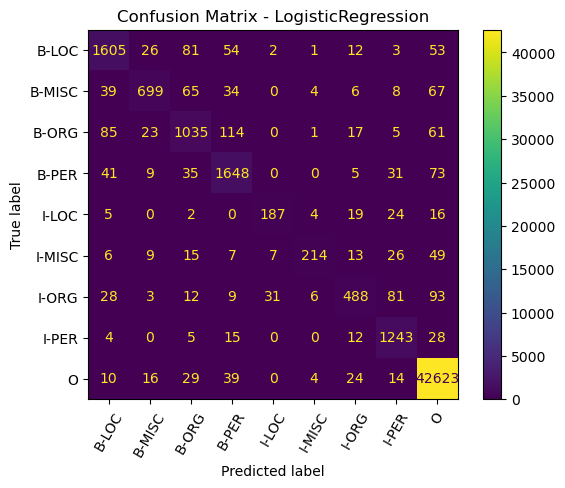


Evaluation for NaiveBayes
Token-level Classification Report
              precision    recall  f1-score   support

       B-LOC     0.7155    0.8966    0.7958      1837
      B-MISC     0.8791    0.6703    0.7606       922
       B-ORG     0.7207    0.7159    0.7183      1341
       B-PER     0.8859    0.7964    0.8388      1842
       I-LOC     0.9130    0.3268    0.4814       257
      I-MISC     0.9524    0.4046    0.5680       346
       I-ORG     0.6441    0.6338    0.6389       751
       I-PER     0.8679    0.9350    0.9002      1307
           O     0.9850    0.9902    0.9876     42759

    accuracy                         0.9531     51362
   macro avg     0.8404    0.7077    0.7433     51362
weighted avg     0.9545    0.9531    0.9516     51362

Confusion Matrix
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
[[ 1647    19    84    26     0     0     1     1    59]
 [   65   618    75    31     0     1     6     7   119]
 [  176    21  

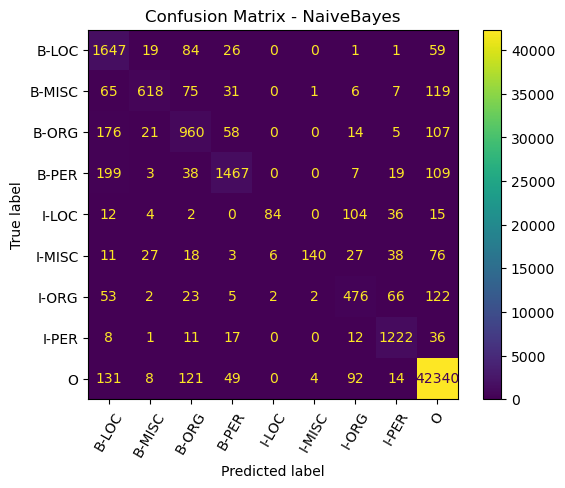


Evaluation for SVM
Token-level Classification Report
              precision    recall  f1-score   support

       B-LOC     0.8946    0.9151    0.9047      1837
      B-MISC     0.8855    0.8221    0.8526       922
       B-ORG     0.8582    0.8397    0.8489      1341
       B-PER     0.9231    0.9446    0.9337      1842
       I-LOC     0.7897    0.7743    0.7819       257
      I-MISC     0.8445    0.6908    0.7599       346
       I-ORG     0.8041    0.7270    0.7636       751
       I-PER     0.9377    0.9449    0.9413      1307
           O     0.9936    0.9969    0.9952     42759

    accuracy                         0.9764     51362
   macro avg     0.8812    0.8506    0.8647     51362
weighted avg     0.9759    0.9764    0.9760     51362

Confusion Matrix
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
[[ 1681    23    67    35     3     0    11     0    17]
 [   37   758    42    16     0     4     5     2    58]
 [   84    20  1126   

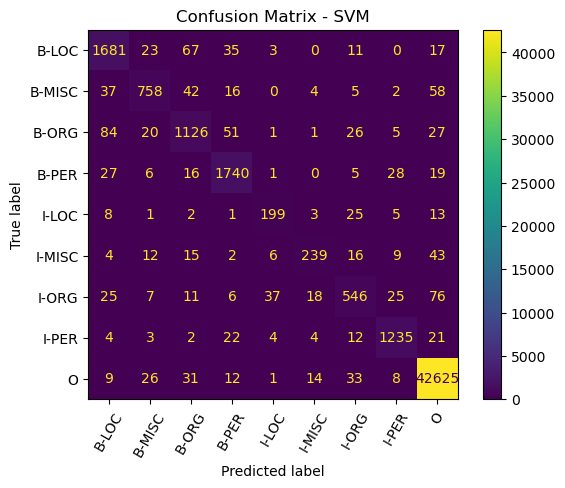

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def read_conll_file(filename):
    """
    Reads a CoNLL file and returns a list of labels per token.
    """
    labels = []
    with open(filename, 'r', encoding='utf8') as f:
        for line in f:
            line = line.strip()
            if line == "":
                continue
            parts = line.split()
            labels.append(parts[-1])
    return labels

gold_file = "../../data/conll2003/conll2003.dev.conll"  # Gold labels

#Dictionary mapping model names to prediction files
prediction_files = {
    "LogisticRegression": "dev_predictions.logreg.conll",
    "NaiveBayes": "dev_predictions.NB.conll",
    "SVM": "dev_predictions.SVM.conll"
}

for model_name, pred_file in prediction_files.items():
    print(f"\nEvaluation for {model_name}")
    
    y_true = read_conll_file(gold_file)
    y_pred = read_conll_file(pred_file)
    
    #classification report
    print("Token-level Classification Report")
    print(classification_report(y_true, y_pred, digits=4))
    
    #Confusion matrix
    labels = sorted(list(set(y_true + y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print("Confusion Matrix")
    print("Labels:", labels)
    print(cm)
    
    #Visualize 
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    display.plot(xticks_rotation=60)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction import DictVectorizer

# Convert features to sparse and combine with embeddings
vec = DictVectorizer()
features_onehot = vec.fit_transform(train_features)
train_embeddings_sparse = csr_matrix(embedding_features_train)
features_combined = hstack([features_onehot, train_embeddings_sparse])

# Define SVM and hyperparameter grid
svm = LinearSVC(max_iter=10000)

param_grid = {'C': [0.5, 0.6, 0.7], 'loss': ['hinge', 'squared_hinge']}

#Grid search with 2-fold cross-valiadation
grid_search = GridSearchCV(svm, param_grid, cv=2, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(features_combined, train_targets)

print("Best parameters:", grid_search.best_params_)
print("Best macro F1:", grid_search.best_score_)

#Use best estimator
best_svm = grid_search.best_estimator_

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best parameters: {'C': 0.6, 'loss': 'squared_hinge'}
Best macro F1: 0.8148351300971934


In [22]:
#Extract one-hot features
vec = DictVectorizer()
features_onehot = vec.fit_transform(train_features) 

#Convert embeddings to sparse
train_embeddings_sparse = csr_matrix(embedding_features_train)

#Combine one-hot features + embeddings for SVM
features_combined = hstack([features_onehot, train_embeddings_sparse])

#SVM with best hyperparameters
final_svm = LinearSVC(max_iter=10000, C=0.6, loss='squared_hinge')
final_svm.fit(features_combined, train_targets)

#Predict on dev 
features_dev_onehot = vec.transform(extract_features_and_labels(devfile)[0])
dev_embeddings_sparse = csr_matrix(embedding_features_dev)
features_dev_combined = hstack([features_dev_onehot, dev_embeddings_sparse])

predictions = final_svm.predict(features_dev_combined)

outputfile_tuned = "dev_predictions.SVM_tuned.conll"
with open(outputfile_tuned, 'w', encoding='utf8') as outfile:
    counter = 0
    for line in open(devfile, 'r', encoding='utf8'):
        if len(line.rstrip('\n').split()) > 0:
            outfile.write(line.rstrip('\n') + '\t' + predictions[counter] + '\n')
            counter += 1

print("Tuned SVM predictions saved to", outputfile_tuned)


Tuned SVM predictions saved to dev_predictions.SVM_tuned.conll


Token-level Classification Report for Tuned SVM
              precision    recall  f1-score   support

       B-LOC     0.8972    0.9173    0.9071      1837
      B-MISC     0.8845    0.8221    0.8522       922
       B-ORG     0.8615    0.8397    0.8505      1341
       B-PER     0.9218    0.9473    0.9344      1842
       I-LOC     0.7905    0.7782    0.7843       257
      I-MISC     0.8582    0.6821    0.7601       346
       I-ORG     0.8148    0.7204    0.7647       751
       I-PER     0.9364    0.9464    0.9414      1307
           O     0.9934    0.9970    0.9952     42759

    accuracy                         0.9765     51362
   macro avg     0.8843    0.8501    0.8655     51362
weighted avg     0.9760    0.9765    0.9761     51362

Confusion Matrix
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
[[ 1685    23    65    37     3     0     7     0    17]
 [   38   758    42    16     0     5     4     2    57]
 [   80    22  1126    52   

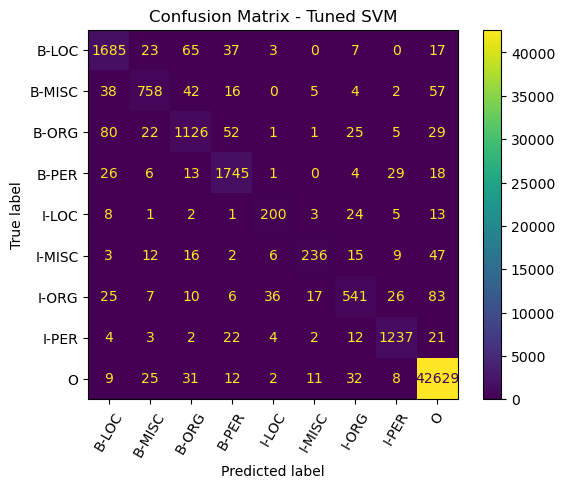

In [23]:
y_true = read_conll_file(gold_file)
y_pred = read_conll_file("dev_predictions.SVM_tuned.conll")  #tuned SVM predictions

#classification report
print("Token-level Classification Report for Tuned SVM")
print(classification_report(y_true, y_pred, digits=4))

#Confusion matrix
labels = sorted(list(set(y_true + y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)
print("Confusion Matrix")
print("Labels:", labels)
print(cm)

#Visualize
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display.plot(xticks_rotation=60)
plt.title("Confusion Matrix - Tuned SVM")
plt.show()

In [8]:
#To make sure i am using LR because I previously haven't stored it in a variable exxplicitly but in a loop
lr_model, vec = create_classifier(train_features, train_targets, modelname='logreg')

#Define feature groups to ablate
feature_groups = {'token_surface', 'capitalization', 'shape', 'pos', 'chunk', 'prev_token'}


In [9]:
def extract_features_with_selection(datafile, groups_to_use):
    """
    Extract features but only keep feature groups listed in groups_to_use.
    """
    data = []
    targets = []
    prev_token = None
    prev_pos = None

    with open(datafile, 'r', encoding='utf8') as infile:
        for line in infile:
            comps = line.rstrip('\n').split()
            if len(comps) == 0:
                continue

            token, pos_tag, chunk_tag = comps[:3]

            feats = {
                'token': token,
                'token.lower()': token.lower(),
                'is_capitalized': token[0].isupper(),
                'is_all_caps': token.isupper(),
                'is_all_lower': token.islower(),
                'contains_digit': any(ch.isdigit() for ch in token),
                'contains_hyphen': '-' in token,
                'pos_tag': pos_tag,
                'chunk_tag': chunk_tag,
                'prev_token': prev_token if prev_token else 'BOS',
                'prev_pos': prev_pos if prev_pos else 'BOS'
            }

            # feature groups
            group_map = {
                'token_surface': ['token', 'token.lower()'],
                'capitalization': ['is_capitalized', 'is_all_caps', 'is_all_lower'],
                'shape': ['contains_digit', 'contains_hyphen'],
                'pos': ['pos_tag', 'prev_pos'],
                'chunk': ['chunk_tag'],
                'prev_token': ['prev_token']
            }

            #filter features
            filtered = {}
            for g in groups_to_use:
                for key in group_map[g]:
                    filtered[key] = feats[key]

            data.append(filtered)
            targets.append(comps[-1])

            prev_token = token
            prev_pos = pos_tag

    return data, targets


In [10]:
def run_ablation_with_lr(devfile, feature_groups, vec, lr_model):
    """
    Runs feature ablation on dev set using already trained Logistic Regression model.
    """
    # Full model performance
    full_feats_dict, full_labels = extract_features_with_selection(devfile, feature_groups)
    full_features_onehot = vec.transform(full_feats_dict)
    full_pred = lr_model.predict(full_features_onehot)
    full_f1 = f1_score(full_labels, full_pred, average='macro')

    print("\nFull model")
    print("F1 =", full_f1)

    results = []

    for ablated_group in feature_groups:
        used_groups = feature_groups - {ablated_group}

        dev_feats_dict, dev_labels = extract_features_with_selection(devfile, used_groups)
        dev_features_onehot = vec.transform(dev_feats_dict)

        pred = lr_model.predict(dev_features_onehot)
        f1 = f1_score(dev_labels, pred, average='macro')

        results.append({
            "ablated": ablated_group, "f1": f1, "predictions": pred, "gold": dev_labels
        })

        print("Ablated", ablated_group, "F1:", f1, "Change:", f1 - full_f1)

    return results

In [11]:
ablation_results = run_ablation_with_lr(devfile, feature_groups, vec, lr_model)


Full model
F1 = 0.8330436955596265
Ablated shape F1: 0.8326261858667876 Change: -0.00041750969283893546
Ablated chunk F1: 0.8189449580923585 Change: -0.014098737467268085
Ablated token_surface F1: 0.5297608757073388 Change: -0.3032828198522878
Ablated prev_token F1: 0.7598966709785592 Change: -0.07314702458106737
Ablated capitalization F1: 0.7035934418922866 Change: -0.12945025366733998
Ablated pos F1: 0.6501044165794977 Change: -0.18293927898012885


In [13]:
train_feats_dict, train_labels = extract_features_and_labels(trainingfile)
full_feats_dict, full_labels  = extract_features_and_labels(devfile)
full_features_onehot = vec.transform(full_feats_dict)
# Predictions
full_pred = lr_model.predict(full_features_onehot)

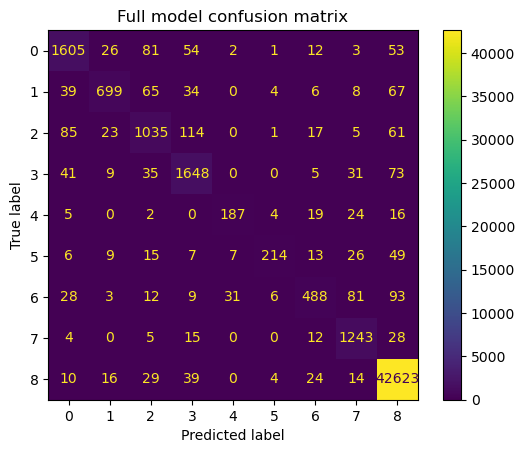

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
#Full LR model for error analysis
cm = confusion_matrix(full_labels, full_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Full model confusion matrix")
plt.show()

In [21]:
from collections import Counter, defaultdict
#model predictions
full_feats_dict, full_labels = extract_features_with_selection(devfile, feature_groups)
full_features_onehot = vec.transform(full_feats_dict)
full_pred = lr_model.predict(full_features_onehot)

errors = [(true, pred) for true, pred in zip(full_labels, full_pred) if true != pred]

#most common errors
error_counts = Counter(errors)
most_common_errors = error_counts.most_common(10)

print("Most common errors (true, predicted):")
for (true, pred), count in most_common_errors:
    print(f"{true}, {pred}: {count} times")

Most common errors (true, predicted):
B-ORG, B-PER: 114 times
I-ORG, O: 93 times
B-ORG, B-LOC: 85 times
B-LOC, B-ORG: 81 times
I-ORG, I-PER: 81 times
B-PER, O: 73 times
B-MISC, O: 67 times
B-MISC, B-ORG: 65 times
B-ORG, O: 61 times
B-LOC, B-PER: 54 times


In [22]:
total_counts = Counter(full_labels)
error_rates = {}

for (true_label, predicted_label), num_errors in error_counts.items():
    error_rates[(true_label, predicted_label)] = num_errors / total_counts[true_label]

print("\nTop 10 error types normalized") #this is to avoid common labels dominating the count
for (true_label, predicted_label), rate in sorted(error_rates.items(), key=lambda x: x[1], reverse=True)[:10]:

    num_errors = error_counts[(true_label, predicted_label)]
    print(f"{true_label}, {predicted_label}: {num_errors} mistakes, error rate: {rate:.1%}")


Top 10 error types normalized
I-MISC, O: 49 mistakes, error rate: 14.2%
I-ORG, O: 93 mistakes, error rate: 12.4%
I-ORG, I-PER: 81 mistakes, error rate: 10.8%
I-LOC, I-PER: 24 mistakes, error rate: 9.3%
B-ORG, B-PER: 114 mistakes, error rate: 8.5%
I-MISC, I-PER: 26 mistakes, error rate: 7.5%
I-LOC, I-ORG: 19 mistakes, error rate: 7.4%
B-MISC, O: 67 mistakes, error rate: 7.3%
B-MISC, B-ORG: 65 mistakes, error rate: 7.0%
B-ORG, B-LOC: 85 mistakes, error rate: 6.3%


In [29]:
top_2 = sorted(error_rates.items(), key=lambda x: x[1], reverse=True)[:2]
top_error_types = [(true_label, predicted_label) for (true_label, predicted_label), _ in top_2]

print("\nTop 2 error types")
for true_label, predicted_label in top_error_types:
    print(f"{true_label}, {predicted_label}")



Top 2 error types
I-MISC, O
I-ORG, O


In [30]:
features_to_use = [
    'token', 'token.lower()', 'is_capitalized', 'is_all_caps', 'is_all_lower',
    'contains_digit', 'contains_hyphen', 'pos_tag', 'chunk_tag',
    'prev_token', 'prev_pos']

In [42]:
#Error analysis for top 2 including wrong and correct instances 
from collections import Counter

for target_error in top_error_types:
    print(f"\nError type: True:{target_error[0]}, Predicted:{target_error[1]}")

    # Errors
    error_instances = [
        feat for feat, true_label, pred_label in zip(full_feats_dict, full_labels, full_pred)
        if (true_label, pred_label) == target_error
    ]
    print(f"Total errors: {len(error_instances)}")

    # Correct instances with same gold label
    correct_instances = [
        feat for feat, true_label, pred_label in zip(full_feats_dict, full_labels, full_pred)
        if true_label == target_error[0] and true_label == pred_label
    ]
    print(f"Total correct with same true label: {len(correct_instances)}")

    # Count features 
    feature_counts_errors = {fname: Counter() for fname in features_to_use}
    for feat in error_instances:
        for fname in features_to_use:
            feature_counts_errors[fname][feat.get(fname, 'None')] += 1

    feature_counts_correct = {fname: Counter() for fname in features_to_use}
    for feat in correct_instances:
        for fname in features_to_use:
            feature_counts_correct[fname][feat.get(fname, 'None')] += 1

    # comparison 
    for fname in features_to_use:
        print(f"\nFeature '{fname}':")
        print("  Errors:")
        for val, count in feature_counts_errors[fname].most_common(5):
            pct = (count / len(error_instances) * 100) if len(error_instances) > 0 else 0
            print(f"    {val}: {count} times ({pct:.1f}%)")
        print("  Correct:")
        for val, count in feature_counts_correct[fname].most_common(5):
            pct = (count / len(correct_instances) * 100) if len(correct_instances) > 0 else 0
            print(f"    {val}: {count} times ({pct:.1f}%)")



Error type: True:I-MISC, Predicted:O
Total errors: 49
Total correct with same true label: 214

Feature 'token':
  Errors:
    of: 11 times (22.4%)
    the: 4 times (8.2%)
    96: 3 times (6.1%)
    for: 2 times (4.1%)
    TOURNAMENT: 2 times (4.1%)
  Correct:
    Cup: 29 times (13.6%)
    Open: 18 times (8.4%)
    CUP: 18 times (8.4%)
    League: 13 times (6.1%)
    DIVISION: 12 times (5.6%)

Feature 'token.lower()':
  Errors:
    of: 11 times (22.4%)
    the: 4 times (8.2%)
    96: 3 times (6.1%)
    for: 2 times (4.1%)
    a: 2 times (4.1%)
  Correct:
    cup: 47 times (22.0%)
    open: 24 times (11.2%)
    league: 22 times (10.3%)
    division: 12 times (5.6%)
    korean: 10 times (4.7%)

Feature 'is_capitalized':
  Errors:
    False: 32 times (65.3%)
    True: 17 times (34.7%)
  Correct:
    True: 207 times (96.7%)
    False: 7 times (3.3%)

Feature 'is_all_caps':
  Errors:
    False: 42 times (85.7%)
    True: 7 times (14.3%)
  Correct:
    False: 157 times (73.4%)
    True: 57 t

In [40]:
from collections import defaultdict, Counter

#map token to labels
train_token_labels = defaultdict(set)
for feat, label in zip(train_feats_dict, train_labels):
    train_token_labels[feat['token']].add(label)

#Ambiguity
for target_error in top_error_types:
    print(f"\nError type: {target_error[0]}, {target_error[1]}")

    ambiguous_tokens = []
    total_error_tokens = 0

    for feat, true_label, pred_label in zip(full_feats_dict, full_labels, full_pred):
        if (true_label, pred_label) == target_error:
            total_error_tokens += 1
            token = feat['token']
            if len(train_token_labels[token]) > 1:
                ambiguous_tokens.append(token)

    print(f"Total errors of this type: {total_error_tokens}")
    print(f"Ambiguous-token errors: {len(ambiguous_tokens)} "
          f"({len(ambiguous_tokens)/total_error_tokens:.2%})")

    # Top ambiguous tokens
    ambiguous_token_counts = Counter(ambiguous_tokens)
    print("Top ambiguous tokens:")
    for token, count in ambiguous_token_counts.most_common(5):
        print(f"  {token}: {count}")



Error type: I-MISC, O
Total errors of this type: 49
Ambiguous-token errors: 31 (63.27%)
Top ambiguous tokens:
  of: 11
  the: 4
  96: 3
  for: 2
  A: 1

Error type: I-ORG, O
Total errors of this type: 93
Ambiguous-token errors: 81 (87.10%)
Top ambiguous tokens:
  (: 13
  ): 13
  's: 12
  of: 11
  and: 6
